In [3]:
import pandas as pd

from rstt import BasicPlayer, BTRanking, BetterWin, SwissBracket
from simulation.bracketframe import bracketFrame

import random
random.seed(40)

# Expected Matching Approach – Simulation Benchmark

### Goals
- Reproduce example scenarios.
- Test relevant matching policies and compare them to the **EMA Rotation** matching strategy.
- Evaluate which teams qualify with respect to **true skill level** and **a priori seeding**.
- Assess format robustness across different population distributions and seeding qualities

### Tool
**[RSTT](https://github.com/Ematrion/rstt)**, a Python framework for simulation-based research.


### Comparative Study Overview

We conduct a comparative study of different matching policies, algorithms, or pairing systems.  
The evaluation is performed across a **configuration matrix** defined by three key experimental factors:  

1. **Solver** (Game Outcome Generator)
   - BetterWin: Deterministic - higher skill always wins
   - Logistic: Stochastic - win probability based on skill difference
   - MinEffort: Simulates top teams underperforming in early rounds

2. **Population** (Team Skill Distribution)
   - Gaussian: Normal distribution of skills
   - Pareto: Heavy-tailed distribution (few dominant teams)
   - Weibull: Intermediate distribution
   - GPR_teams: Real Elo ratings from Riot's 2024 [Global Power Ranking](https://lolesports.com/en-GB/gpr/2024/split-2)

3. **Seeding Class** (Initial Ranking Quality)
   - ACR2: Top 8 and bottom 8 shuffled separately
   - ACR3: Top 4, middle 8, bottom 4 shuffled separately  
   - ACR5: Top 5, middle 6, bottom 5 shuffled separately
   - RANDOM: Completely random seeding

This results in multiple experimental configurations covering all combinations of these factors. Each configuration is tested to assess system performance, fairness, and robustness under varying conditions.


### Output

The notebook results in a dataset of .csv files with computed parameters and computed metrics. 


## 0. Simulation Basics

We load a csv containing the game results of the Twitter example. We create `rstt.Player` instances to represent each involved team. A level is assigned to each team according to their seed, ensuring that high seed have higher level.

### Understanding the Setup

This section establishes the baseline scenario:
- **16 teams** from the Graham Pitt Twitter example
- **Skill levels** assigned proportional to seeds (Heroic=1600, Cloud9=1500, ..., Team 500=100)
- **Perfect correlation** between initial seeds and true skill (unrealistic but useful for validation)

This idealized scenario allows us to:
1. Verify that our simulation reproduces the problematic Twitter example
2. Establish a baseline for comparison with more realistic scenarios
3. Test if proposed solutions actually solve the identified problem

**Note:** In practice, initial seeds are never perfectly correlated with true skill - this is precisely why we need robust matching algorithms!

In [4]:
example = pd.read_csv('data/examples/graham_pit_example.csv', index_col=0, keep_default_na=False)
names = example['Team'].values
levels = [(16-i)*100 for i in range(0,16)]
teams = [BasicPlayer(name, level) for name, level in zip(names, levels)]
seeds = BTRanking('Seedings', teams)
seeds.plot()

----------- Seedings -----------
   0.               Heroic       1600
   1.               Cloud9       1500
   2.               Spirit       1400
   3.                  BIG       1300
   4.                 Ence       1200
   5.             Vitality       1100
   6.                  NIP       1000
   7.                 9INE        900
   8.                   G2        800
   9.         Eternal Fire        700
  10.             Astralis        600
  11.                Monte        500
  12.              iNation        400
  13.               Aurora        300
  14.                Forze        200
  15.             Team 500        100


## 1. SwissBracket Matching Systems

This section presents various implementations of the Swiss Bracket format, each using different matching algorithms. All runs in this section use:
- **BetterWin() solver**: Game outcomes are deterministic - the higher-skilled team always wins
- **Perfect seeding**: Seeds exactly match true skill levels (seeds from section 0)

### Multiple Implementations for comparative study

We test several variants to understand:
- **Default RSTT behavior**: What happens with naive matching?
- **Example Reproduction**: Can we recreate the problematic Twitter scenario?
- **Current Major format**: How does Valve's implemented solution perform?
- **EMA Rotation**: Does the proposed solution actually work?

### Reading the Results Tables

Each results table shows:
- **Team**: Team name
- **Seed**: Initial seeding position (1 = best)
- **Rounds 1-5**: Opponent and result (win/lose) for each round
  - Teams that qualify early (3-0) or eliminate early (0-3) don't play all 5 rounds
  - Final qualification decisions happen in Round 5 for the 2-2 teams

### 1.1 SwissBracket Default Implementation

The rstt package provides a SwissBracket class for the tournament under study. However, its default implementation does not emulate the example. Furthermore a **duplicate game** is produced: **Ence versus G2** played in both $Round_3$ and $Round_5$.


In [5]:
sb = SwissBracket('RSTT', seeds, BetterWin())
sb.registration(teams)
sb.run()
sb_df = bracketFrame(sb)
sb_df

/Users/dbucher/Documents/GitHub/SwissBracketMatching/.venv/lib/python3.13/site-packages/rstt/utils/competition.py:46: RuntimeWarning: No Valid matchups where found
  warnings.warn(msg, RuntimeWarning)


,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,Ence - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,9INE - win,
Ence,Ence,5,Monte - win,BIG - lose,G2 - win,Spirit - lose,G2 - win
Vitality,Vitality,6,Astralis - win,Spirit - lose,Eternal Fire - win,NIP - win,
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,Astralis - win,Vitality - lose,Monte - win
9INE,9INE,8,G2 - win,Heroic - lose,Monte - win,BIG - lose,Astralis - win
G2,G2,9,9INE - lose,Team 500 - win,Ence - lose,Eternal Fire - win,Ence - lose
Eternal Fire,Eternal Fire,10,NIP - lose,Forze - win,Vitality - lose,G2 - lose,


### 1.1.2 Parametrized Default

Here is a glimpse on how to parametrize the SwissBracket class.
To qualify the top8 with minimal intervention, we can simply specify a different *pairings options generator* for the last round - the round where teams with *2 wins and 2 loses* face each others. We also need to tell the tournament to always use the initial seeds for every round and not just the initial one.

As we can see, not only there are no more duplicate encounters, but the **top8 is qualified**.

**Key Changes:**
- `def_seeder=InitialSeeds()`: Always use initial seeding for pairings (no dynamic reseeding)
- `generators[(2,2)] = Chord6()`: Use preferred $K_{3,3}$ matchings for 2-2 teams in Round 5

This simple modification shows that the problem is solvable - but we need to understand **why** it works and whether it's robust.


In [6]:
from simulation.systems.csmajor import Chord6

class InitialSeeds:
    def seed(self, players, initial_seeds, results, *args, **kwargs):
        return [p for p in initial_seeds if p in players]

class SeededChord(SwissBracket):
    def __init__(self, name, seeding, solver):
        super().__init__(name, seeding, solver,
                         def_seeder=InitialSeeds()
                        )
        self.generators[(2,2)] = Chord6()

sc = SeededChord('SeededChord_x', seeds, BetterWin())
sc.registration(teams)
sc.run()
sc_df = bracketFrame(sc)
sc_df

,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,G2 - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,9INE - win,
Ence,Ence,5,Monte - win,BIG - lose,NIP - win,Vitality - win,
Vitality,Vitality,6,Astralis - win,Spirit - lose,Monte - win,Ence - lose,G2 - win
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,Ence - lose,Aurora - win,Astralis - win
9INE,9INE,8,G2 - win,Heroic - lose,Astralis - win,BIG - lose,Eternal Fire - win
G2,G2,9,9INE - lose,Team 500 - win,Eternal Fire - win,Spirit - lose,Vitality - lose
Eternal Fire,Eternal Fire,10,NIP - lose,Forze - win,G2 - lose,iNation - win,9INE - lose


### 1.2 Example Reproduction

To reproduce the original example from the tweet, we need to specify the **F1_CROSS** $K_{4,4}$ coloring and extend it in the first round for all 8 games. We need to provide Valve preferred matching for all games between in round 4 and 5. We also specify the solkoff tiebreaker policy for the entire tournament run. 

**Implementation Details:**
- Uses the Cross algorithm from the theoretical notebook
- Uses Solkoff tiebreaker 

As we can see, in the Example reproduction **Astralis does qualify** beating Monte in place of **9INE who lost against Vitality**.

**Critical Observation:** 
This exactly matches the problematic scenario from Twitter, confirming that:
1. Our simulation framework accurately models the example tournament
2. The theoretical analysis correctly identified the issue
3. The problem is reproducible and predictable

In [7]:
from utils import R1Ema, SimpleGen, F1_CROSS_0123, F1_ROT_0132
from simulation.systems.csmajor import SpeedUp, Chord6
from simulation.systems.tiebreaker import TieBreakReSeeder


class OriginalMajor(SwissBracket):
    def __init__(self, name, seeding, solver):
        
        seeds = list(range(16))
        g1, g2 = seeds[4:-4], seeds[:4] + seeds[-4:]
        # Implemented using EMA cross algorithm
        k44 = SimpleGen(F1_CROSS_0123)
        
        chord6 = Chord6()
        generators={(0,0): R1Ema(k44, g1, g2),
                    (1,1): k44,
                    (2,2): chord6,
                    (2,1): chord6,
                    (1,2): chord6,
                   }
        super().__init__(name=name, seeding=seeding, solver=solver,
                         generators=generators,
                         def_seeder=TieBreakReSeeder(seeding=seeding, policies=['solkoff']),
                        )
        self.registration([p for p in seeding])


example_repro = OriginalMajor('Ema Major', seeds, BetterWin())
example_repro.run()
ex_df = bracketFrame(example_repro)
if ex_df.equals(example):
    print("Simulation reproduces the twitter example !")

ex_df

Simulation reproduces the twitter example !


,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,Ence - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,Vitality - win,
Ence,Ence,5,Monte - win,BIG - lose,Astralis - win,Spirit - lose,G2 - win
Vitality,Vitality,6,Astralis - win,Spirit - lose,Monte - win,BIG - lose,9INE - win
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,G2 - win,9INE - win,
9INE,9INE,8,G2 - win,Heroic - lose,Eternal Fire - win,NIP - lose,Vitality - lose
G2,G2,9,9INE - lose,Team 500 - win,NIP - lose,Eternal Fire - win,Ence - lose
Eternal Fire,Eternal Fire,10,NIP - lose,Forze - win,9INE - lose,G2 - lose,



### 1.2.2 Current Major format

To enforce Valve's rule and the proposal of Graham Pitt, it uses **speed-up pairings** in the first round (pairing 1vs9, 2vs10, etc.). 

In the new rules, the **top8 seed do indeed qualify**.

**Why does this work in this specific scenario?**
- Perfect seeds ✓
- Deterministic outcomes (BetterWin) ✓
- All games play out exactly as expected ✓

**But the key question remains:** Is this robust when seeds are imperfect or outcomes are stochastic? The subsequent simulation study will answer this.

In [8]:
from rstt.utils import utils as uu, matching as um, competition as uc
from simulation.systems.csmajor import GrahamPittSolution

class CurrentMajor(OriginalMajor):
    def __init__(self, name, seeding, solver):
        super().__init__(name=name, seeding=seeding, solver=solver)
        self.generators[(0,0)] = SpeedUp()

major_repro = CurrentMajor('Current Major', seeds, BetterWin())
major_repro.run()
maj_df = bracketFrame(major_repro)

maj_df

,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,G2 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Eternal Fire - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Astralis - win,Vitality - win,Cloud9 - lose,9INE - win,
BIG,BIG,4,Monte - win,Ence - win,Heroic - lose,NIP - win,
Ence,Ence,5,iNation - win,BIG - lose,Monte - win,Vitality - win,
Vitality,Vitality,6,Aurora - win,Spirit - lose,Astralis - win,Ence - lose,Eternal Fire - win
NIP,NIP,7,Forze - win,Cloud9 - lose,Eternal Fire - win,BIG - lose,G2 - win
9INE,9INE,8,Team 500 - win,Heroic - lose,G2 - win,Spirit - lose,Astralis - win
G2,G2,9,Heroic - lose,Team 500 - win,9INE - lose,Aurora - win,NIP - lose
Eternal Fire,Eternal Fire,10,Cloud9 - lose,Forze - win,NIP - lose,iNation - win,Vitality - lose


### 1.2.3 Limitations

The discussion that led to the current design of the major is centered about qualifying the top8 seeds. Yet seeding is just an arbitrary permutation of the *real skilled based ranking*. 

The following construction illustratse the limitation of such approach. It is the current major implementation with *speed up* pairings in the first round. It does follow the *BetterWin* heuristic, but based on *skill* not seedings. The Initial seedings are slightly incorrect, but the top8 teams are preserved.

Despite all the narrative, we observe many **similarities with the original example:**
- All games of round 1 % 2 are the same.
- Heroic & Cloud9 qualify both in round 3
- Spirit, Big & NIP qualify in Round 4
- Ence, Vitality qualify in Round 5
- Seed 8, and actual 8th best team - 9INE - loses in the last round against Vitality (seed 6 and actual 6th best team)
- The 5th round matching is not one of the 6 favoured pairings according to Valve Rulebook.
- A decisif game is played between two bottom 8 seeded teams - Astralis or G2 versus Monte.

**What differs:**
- It is the (3,7) scenario with NIP seeds 3 on $K_{4,4}$ and Eternal Fire seed 7.
- The 9th best team qualifies instead of the 11th, an improvement
- Seed 16 qualify instead of seed 11.

**THE DRAMATIC EFFECT:** 
In the original example, Astralis qualifies over 9INE - but these two teams never faced each other. You could imagine that Astralis *could have* beaten 9INE. 

In the example below, **G2 - seed 16 - qualifies over 9INE - seed 8 - despite losing the direct confrontation in Round 1.**


### Key Insight

Focusing solely on "getting the right seeds qualified" misses the point. The format should:
1. ✓ Handle imperfect seeds gracefully
2. ✓ Respect head-to-head results
3. ✓ Provide fair matchups in deciding rounds
4. ✓ Be robust across different scenarios

The speed-up matching approach is not an improvement when reality deviates even slightly from perfect seeds.

In [7]:
from scipy.stats import kendalltau


new_seeds = BTRanking('Seedins Importance', teams)
new_seeds.rerank(list(range(8))+list(range(15,7,-1)))

major_biased = CurrentMajor('Current Major', new_seeds, BetterWin())
major_biased.run()
maj_biased = bracketFrame(major_biased)

print("seeds - skills correlation: ", kendalltau(seeds[teams], new_seeds[teams]))

maj_biased

seeds - skills correlation:  SignificanceResult(statistic=np.float64(0.5333333333333333), pvalue=np.float64(0.0033409618582506315))


,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,Ence - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,Vitality - win,
Ence,Ence,5,Monte - win,BIG - lose,G2 - win,Spirit - lose,Astralis - win
Vitality,Vitality,6,Astralis - win,Spirit - lose,Eternal Fire - win,BIG - lose,9INE - win
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,Astralis - win,9INE - win,
9INE,9INE,8,G2 - win,Heroic - lose,Monte - win,NIP - lose,Vitality - lose
Team 500,Team 500,9,Heroic - lose,G2 - lose,iNation - lose,,
Forze,Forze,10,Cloud9 - lose,Eternal Fire - lose,Aurora - lose,,


### 1.5 Expected Matching Approach - Ordered F1 Rotation

My proposed implementation with *F1_ROT* performs well in the **Ideal scenario**, Top 8 teams are qualified without intervention of tiebreaker


### 1.5 Expected Matching Approach - Ordered F1 Rotation

My proposed implementation with **F1_ROT** performs well in the **Ideal scenario**: Top 8 teams are qualified without intervention of tiebreaker.

**Implementation:**
- Uses the Rotation algorithm from the theoretical notebook
- Guarantees valid $K_{3,3}$ matching in Round 5 regardless of which teams reach 2-2
- No tiebreaker needed - the matching structure itself ensures fairness

**Results:** ✅ All top 8 teams qualify

This demonstrates that the EMA Rotation approach solves the problem in the perfect seed scenario. The next sections will test whether this advantage holds under realistic conditions.

In [8]:
### Expected Matching Approach - Ordered F1 Rotation

class EmaRound(SwissBracket):
    def __init__(self, name, seeding, solver, variant=F1_ROT_0132):
        tbrs = InitialSeeds()
        k44 = SimpleGen(variant)
        seeds = list(range(16))
        g1, g2 = seeds[4:-4], seeds[:4] + seeds[-4:]
        r1 = R1Ema(k44, g1, g2)
        chord6 = Chord6()
        generators={(0,0): r1,
                    (1,1): k44,
                    (2,2): chord6,
                    (2,1): chord6,
                    (1,2): chord6,
                   }
        super().__init__(name=name, seeding=seeding, solver=solver,
                         # --- matching --- #
                         generators=generators,
                         def_seeder=tbrs, # type: ignore 
                        )
        self.registration([p for p in seeding])

ema = EmaRound('Ema F1 Rot', seeds, BetterWin())
ema.run()
ema_df = bracketFrame(ema)
ema_df

,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,9INE - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,NIP - win,
Ence,Ence,5,Monte - win,BIG - lose,G2 - win,Vitality - win,
Vitality,Vitality,6,Astralis - win,Spirit - lose,Monte - win,Ence - lose,Eternal Fire - win
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,Astralis - win,BIG - lose,G2 - win
9INE,9INE,8,G2 - win,Heroic - lose,Eternal Fire - win,Spirit - lose,Astralis - win
G2,G2,9,9INE - lose,Team 500 - win,Ence - lose,Aurora - win,NIP - lose
Eternal Fire,Eternal Fire,10,NIP - lose,Forze - win,9INE - lose,iNation - win,Vitality - lose


### 1.6 The Major without tiebreaker

Beacuse I claim tiebreaking does not improve this tournament, I propose remove the solkoff tiebreaker from the original and current major implementation. It keeps just initial seedings for pairings in any rounds.

**Remark** Among all tested systems, Original and OriginalNTB are the only ones where 9INE does not qualify when seeded with the groundtruth ranking and using the BetterWin solver.


In [9]:
class OriginalNTB(OriginalMajor):
    def __init__(self, name, seeding, solver):
        super().__init__(name=name, seeding=seeding, solver=solver)
        self.def_seeder = InitialSeeds()

ontb = OriginalNTB('Original - No tiebreaker', seeds, BetterWin())
ontb.registration(teams)
ontb.run()
ontb_df = bracketFrame(ontb)
ontb_df

,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,Team 500 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Forze - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Aurora - win,Vitality - win,Cloud9 - lose,9INE - win,
BIG,BIG,4,iNation - win,Ence - win,Heroic - lose,NIP - win,
Ence,Ence,5,Monte - win,BIG - lose,Astralis - win,Vitality - win,
Vitality,Vitality,6,Astralis - win,Spirit - lose,Monte - win,Ence - lose,Eternal Fire - win
NIP,NIP,7,Eternal Fire - win,Cloud9 - lose,G2 - win,BIG - lose,9INE - win
9INE,9INE,8,G2 - win,Heroic - lose,Eternal Fire - win,Spirit - lose,NIP - lose
G2,G2,9,9INE - lose,Team 500 - win,NIP - lose,Aurora - win,Astralis - win
Eternal Fire,Eternal Fire,10,NIP - lose,Forze - win,9INE - lose,iNation - win,Vitality - lose


**With or without tiebreaker**, in the current rules, the best 8 teams do qualify in the perfect scenario

In [10]:
class MajorNTB(CurrentMajor):
    def __init__(self, name, seeding, solver):
        super().__init__(name=name, seeding=seeding, solver=solver)
        self.def_seeder = InitialSeeds()

mntb = MajorNTB('Major - No tiebreaker', seeds, BetterWin())
mntb.registration(teams)
mntb.run()
mntb_df = bracketFrame(mntb)
mntb_df

,Team,Seed,Round 1,Round 2,Round 3,Round 4,Round 5
Heroic,Heroic,1,G2 - win,9INE - win,BIG - win,,
Cloud9,Cloud9,2,Eternal Fire - win,NIP - win,Spirit - win,,
Spirit,Spirit,3,Astralis - win,Vitality - win,Cloud9 - lose,9INE - win,
BIG,BIG,4,Monte - win,Ence - win,Heroic - lose,NIP - win,
Ence,Ence,5,iNation - win,BIG - lose,Monte - win,Vitality - win,
Vitality,Vitality,6,Aurora - win,Spirit - lose,Astralis - win,Ence - lose,Eternal Fire - win
NIP,NIP,7,Forze - win,Cloud9 - lose,Eternal Fire - win,BIG - lose,G2 - win
9INE,9INE,8,Team 500 - win,Heroic - lose,G2 - win,Spirit - lose,Astralis - win
G2,G2,9,Heroic - lose,Team 500 - win,9INE - lose,Aurora - win,NIP - lose
Eternal Fire,Eternal Fire,10,Cloud9 - lose,Forze - win,NIP - lose,iNation - win,Vitality - lose


### 1.7 Baseline

The 6 variants will be tested against known alternatives for a top 8 qualification:

- 4 groups of 4 teams 
- 2 groups of 8 teams.

Group stage correspond to a Round Robin among team of a group.

In [11]:
from simulation.systems.sports import GroupStage4, GroupStage8

variants = {'4Groups4': GroupStage4, '2Groups8': GroupStage8,
            'Original': OriginalMajor, 'Original-NTB': OriginalNTB,
            'Major': CurrentMajor, 'Major-NTB': MajorNTB,
            'FixedDefault': SeededChord, 'Ema': EmaRound,
           }


## 2. Parameters

The challenge of designing a simulation-based evaluation of a competitive system is the lack of related work and established benchmarks. 

### Evaluation Philosophy

The experiment has been designed with two key metrics in mind:
1. **Qualification accuracy**: What is the qualification accuracy of a tournament edition - do the "right" teams make it?
2. **Error magnitude**: When the tournament makes an error, how bad is it? (seed 9 instead of seed 8 vs seed 16 instead of seed 8)

These metrics are evaluated across varying conditions to assess **robustness**.


### 2.1 Seeding Classes

We are interested in the **resilience** of the tournament regarding inaccurate ranking. 
We build classes of seedings where certain groups of seeds remain approximately correct.

**Construction:** Seedings are built by applying permutations to the *Ground Truth Ranking* (team skill level in simulation).

**Four Seeding Classes:**

- **RANDOM** (~ACR1): Complete shuffle of all 16 teams
  - *Most realistic for international tournaments with limited cross-region play*
  - Tests format under maximum uncertainty

- **ACR2** (Apriori Correct Round 2): 
  - Shuffle the top 8 internally
  - Shuffle the bottom 8 internally
  - But no team from top 8 receives seed worse than 9
  - *Models accuratly teams scores distribution in $Round_2$"*

- **ACR3**:
  - Shuffle top 4, middle 8, bottom 4 separately
  - *Models accuratly teams scores distribution in $Round_3$"*

- **ACR5**:
  - Shuffle top 5, middle 6, bottom 5 separately
  - *Models accuratly teams scores distribution in $Round_5$"*

**Sample Size:** 50 random seedings per class

The visualization below shows the distribution of kendall-tau correlations between true skill and assigned seeds for each class and top-8 prediction/preservation.


In [12]:
from simulation.seedings import seeding_classes

nb_seeds = 50
seed_classes = seeding_classes(nb_seeds)

for class_name, seedings in seed_classes.items():
    print(class_name, seedings[0], len(seedings))

ACR2 (5, 1, 7, 4, 2, 0, 3, 6, 13, 8, 11, 10, 15, 14, 12, 9) 50
ACR3 (3, 1, 0, 2, 10, 5, 9, 11, 8, 7, 4, 6, 13, 12, 15, 14) 50
ACR5 (2, 4, 1, 3, 0, 6, 5, 10, 7, 9, 8, 11, 15, 13, 14, 12) 50
RANDOM (9, 8, 14, 15, 10, 13, 11, 3, 12, 5, 7, 6, 1, 4, 2, 0) 50


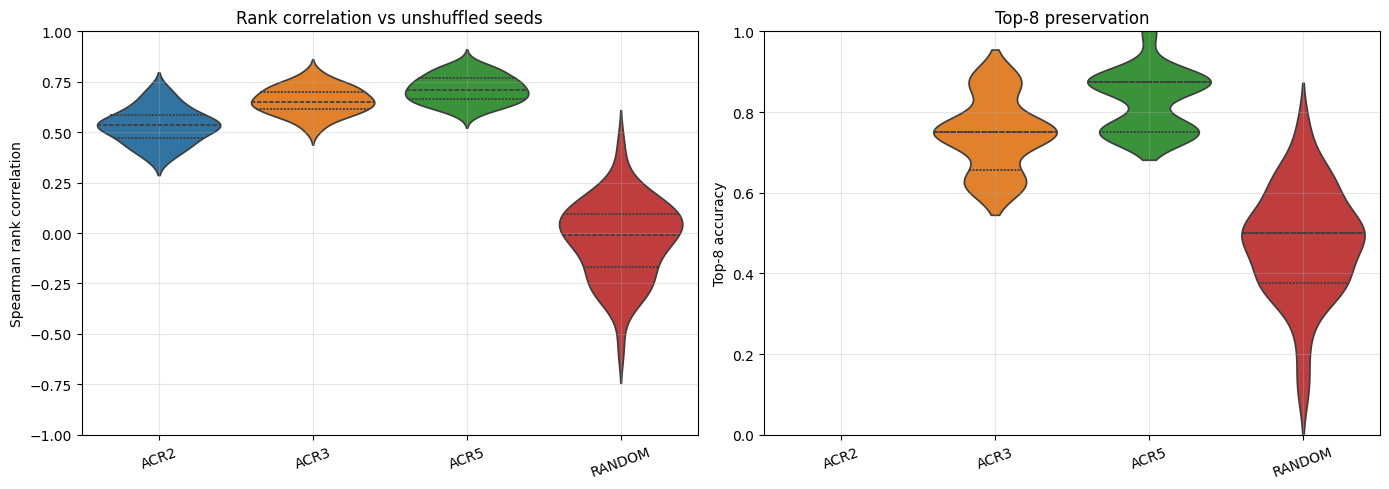

In [13]:
from simulation.seedings import plot_seeding_quality

plot_seeding_quality(seed_classes)

### 2.2 Population Models

LogSolver is a game generator that compute win probabilities based on the Player.level() method (team instances in our case).

We study 4 different population:

- GPR_teams: Elo from the top16 teams of [Riot Global Power Ranking](https://lolesports.com/en-GB/gpr/2024/worlds) in 2024.
- Weibull: level drawn from a weibull distribution with alpha = 1.2, beta= 7.0 , and a scaling factor of 1300.0
- Gaussian: level drawn from a gaussian distribution with mu = 1500 sigma = 250, and a scaling factor of 1.0
- Pareto: level drawn from a pareto distribution with alpha=5.5 and a scaling factor of 1000.0

The below figure present a Probability matrix, and the probability each teams achieve top8 in a RoundRobin.

A round robin is usually consider fair competition as each team face each other exactly once. There is no bias introduce by seedings, and no bias introduce by macthing strategies.



### 2.2 Population Models

**LogSolver** is a game generator that computes win probabilities based on the `Player.level()` method (team instances in our case).

We study 4 different population distributions to model varying competitive landscapes:

#### 1. **GPR_teams** (Real Data)
- Elo ratings from the top 16 teams of [Riot Global Power Ranking](https://lolesports.com/en-GB/gpr/2024/worlds) in 2024
- **Advantage:** Based on real competitive data
- **Models:** Actual skill distribution in elite eSports

#### 2. **Weibull Distribution** 
- Parameters: α = 1.2, β = 7.0, scaling factor = 1300.0
- **Characteristic:** Slightly skewed, intermediate between Gaussian and Pareto
- **Models:** Some dominant teams but still competitive

#### 3. **Gaussian Distribution**
- Parameters: μ = 1500, σ = 250, scaling factor = 1.0
- **Characteristic:** Symmetric bell curve
- **Models:** Highly competitive field, many teams of similar strength
- **Expected behavior:** Most qualification uncertainty in mid-tier

#### 4. **Pareto Distribution**
- Parameters: α = 5.5, scaling factor = 1000.0
- **Characteristic:** Heavy-tailed, few dominant teams
- **Models:** Skill gap between elite and average teams
- **Expected behavior:** Top teams almost always qualify, bottom rarely do


### Understanding the Probability Matrix

The figure below presents:
- **Top:** Probability matrix - P(team i beats team j)
- **Bottom:** Qualification probability (top 8) if format were a Round Robin (baseline for utilitiy loss measure)

A **Round Robin** is usually considered the fairest competition format:
- Each team faces each other exactly once
- No bias from seedings
- No bias from matching strategies
- Pure skill determines outcomes (with stochastic variance)

**Max Utility Loss** (computed below): The difference between:
- Best case: top 8 teams all qualify (sum of their qualification probabilities)
- Worst case: bottom 8 teams all qualify (sum of their qualification probabilities)

This represents the maximum "unfairness" possible - larger values mean clearer skill separation.


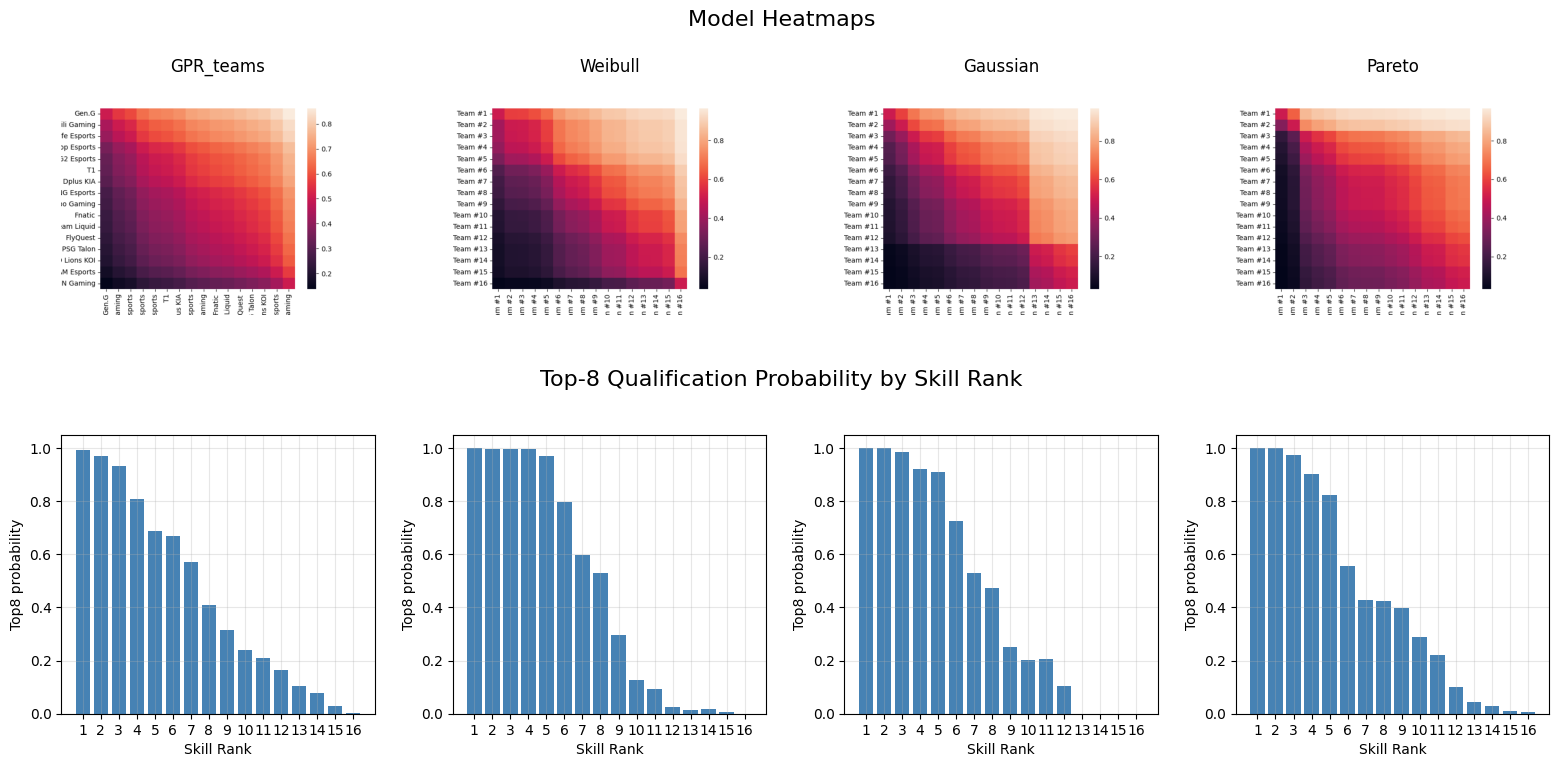

In [14]:
from simulation.baseline import load_population
from simulation.baseline import qualification_probabilities
from simulation.baseline import plot_model_prob

DATA_DIR = "simulation/population"

prob_sampling = 2000
models = load_population(DATA_DIR)
models_probabilities = qualification_probabilities(models, prob_sampling)
plot_model_prob(models_probabilities)

In [15]:
def compute_max_utility_loss(probabilities) -> float:    
    max_score = sum(probabilities[i] for i in range(8))
    min_score = sum(probabilities[i] for i in range(8, 16))
    return max_score - min_score

for model in models_probabilities:
    print(model, compute_max_utility_loss(models_probabilities[model]))

GPR_teams 4.8965000000000005
Weibull 6.297000000000001
Gaussian 5.776000000000001
Pareto 5.0104999999999995


### 2.3 Game Outcome Generators (Solvers)

These determine how game results are generated given team skill levels:

#### **BetterWin** (Deterministic)
- Higher skill always wins
- No upsets, no variance
- **Purpose:** Isolate matching algorithm effects from game randomness
- **Interpretation:** "Perfect execution" scenario

#### **LogSolver** (Stochastic - Logistic)
- Win probability based on skill difference using logistic function
- Allows upsets proportional to skill gap
- **Purpose:** Realistic game outcomes with variance
- **Interpretation:** Standard competitive scenario

#### **MinEffort** (Context-dependent Stochastic)
- Top 4 teams in each population play at reduced skill (60% of true level) in the first 2 rounds
- **Purpose:** Model the *right to lose twice*
- **Interpretation:** "Upset tournament" or pressure effects
- **Rationale:** Top teams may not perform to expectations due to:
  - Overconfidence
  - Opponent preparation
  - Pressure

But truly, top teams do not need to perform at their bests if they can lose. They can use undecisif games as practice games. 
Upset are part of what make great competition entertainning. **A great tournament design could be able to handle these upset fairly.** 


### Why Multiple Solvers?

Different solvers test different aspects:
- **BetterWin:** Tests matching algorithm in isolation
- **Logistic:** Tests robustness to realistic variance
- **MinEffort:** Tests handling of (unexpected) upsets

A good matching algorithm should perform well across all three.

In [16]:
from simulation.protocols import MinEffort
from rstt import LogSolver


min_effort_teams = [team for ranking in models.values() for team in ranking[:4]]
min_effort_levels = [team.level() * 0.6 for team in min_effort_teams]

solvers = {'BetterWin': BetterWin(),
           'Logistic': LogSolver(),
           'MinEffort': MinEffort(min_effort_teams, min_effort_levels),
          }

## 3. Simulation

20 samples over the configuration matrix

In [22]:
from evaluation.analyzer import TournamentAnalyzer
import pandas as pd

data_dir = 'data/results/'
samples = 20
for i in range(samples):
    print('sample', i)
    results, discard = protocol(variants, models, solvers, seed_classes)
    print('analysis')
    analyzer = TournamentAnalyzer(results, models_probabilities, models)
    analyzer.compute_metrics()
    print('dump .csv')
    analyzer.metrics_df.to_csv(data_dir + f"sample_{i+1}.csv")

sample 0
analysis
dump .csv
sample 1
analysis
dump .csv
sample 2
analysis
dump .csv
sample 3
analysis
dump .csv
sample 4
analysis
dump .csv
sample 5
analysis
dump .csv
sample 6
analysis
dump .csv
sample 7
analysis
dump .csv
sample 8
analysis
dump .csv
sample 9
analysis
dump .csv
sample 10
analysis
dump .csv
sample 11
analysis
dump .csv
sample 12
analysis
dump .csv
sample 13
analysis
dump .csv
sample 14
analysis
dump .csv
sample 15
analysis
dump .csv
sample 16
analysis
dump .csv
sample 17
analysis
dump .csv
sample 18
analysis
dump .csv
sample 19
analysis
dump .csv


## 4. Analysis

A quick look at what ahppens from a seed versus level perspective.

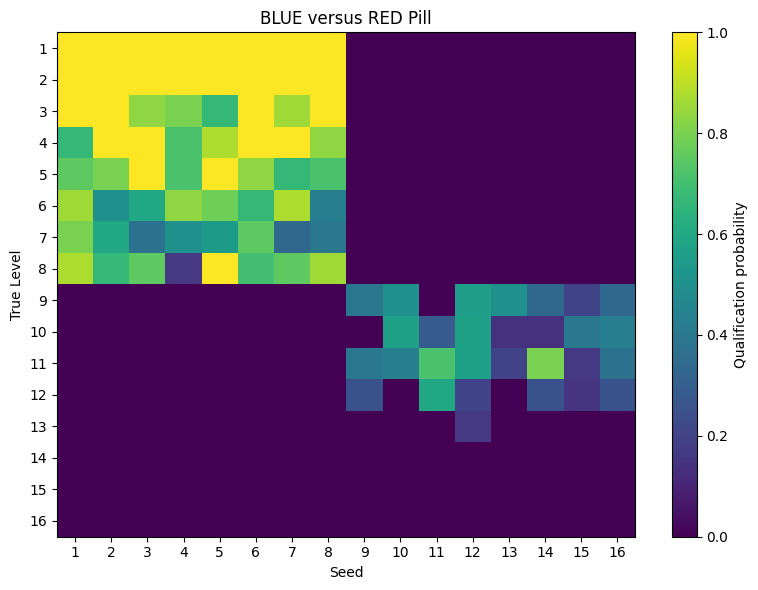

In [18]:
from evaluation.result_matrix import plot_qualif_matrix

s = 'Logistic'
m = 'Gaussian'
sc = 'ACR2'
v = 'Original'

events = results[v][s][m][sc].values()
plot_qualif_matrix(events, models, m)